### Binary Traffic Sign Classification

This is our first notebook on neural networks. We will start by building a simple neural network that will help us to classify two types of traffic signs. The signs used in this lesson are a processed subset from the famous German Traffic Sign Recognition Database (GTSRB) that can be downloaded [here]().

In [10]:
import os
import cv2
from time import time
import numpy as np
from sklearn.utils import shuffle

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 6]

#### Data Loading

Let's now load the data to see what we are dealing with.

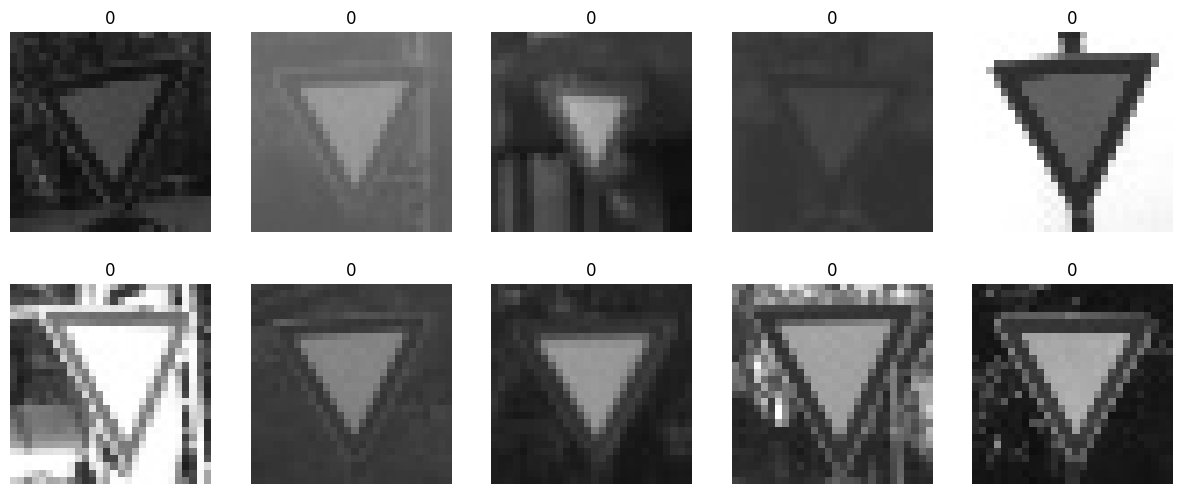

In [13]:
folder = 'data/subset_lecture'

# Load traffic sign class 0
fnames_0 = os.listdir(os.path.join(folder, 'class_id_0'))
images_0 = [cv2.imread(os.path.join(folder, 'class_id_0', f), cv2.IMREAD_UNCHANGED) for f in fnames_0]
labels_0 = [0] * len(images_0)

for cnt, idx in enumerate(np.random.randint(0, len(images_0), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_0[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_0[idx]), plt.axis(False)

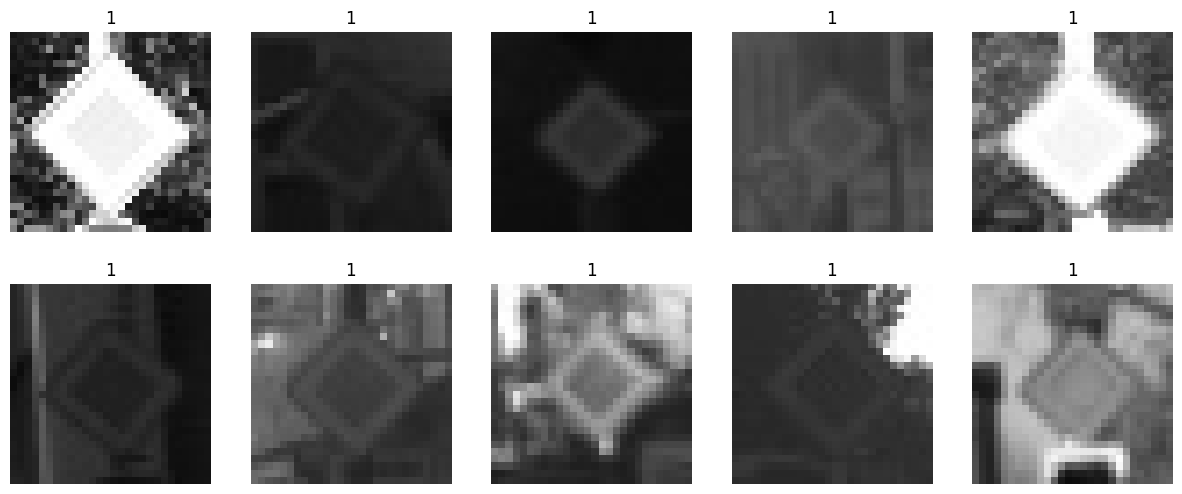

In [15]:
# Load traffic sign class 1
fnames_1 = os.listdir(os.path.join(folder, 'class_id_1'))
images_1 = [cv2.imread(os.path.join(folder, 'class_id_1', f), cv2.IMREAD_UNCHANGED) for f in fnames_1]
labels_1 = [1] * len(images_1)

for cnt, idx in enumerate(np.random.randint(0, len(images_1), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_1[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_1[idx]), plt.axis(False)

In [17]:
print('Num samples class_0', len(images_0))
print('Num samples class_1', len(images_1))

Num samples class_0 2160
Num samples class_1 2100


#### Prepare Input Data

To train our neural network model, we have to prepare the data to the format the the model actually expects. In our case, this will be numpy arrays.

In [20]:
# Put both classes together and shuffle (перетасувати) the data
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

print('Images', images.shape)
print('Labels', labels.shape)

Images (4260, 28, 28)
Labels (4260,)


But now we have a problem. We cannot just feed the image to a neuron since the neuron inputs are flat (one dimensional). On the other hand, the images are 2D matrices. Therefore, we need to "flatten" the images to a one dimensional vector of pixels.
Змінюємо зображення до одновимірного вектора пікселів.

In [23]:
start = time()
pixels = []
for image in images:
    pixels_ = []
    for r in range(image.shape[0]):
        for c in range(image.shape[1]):
            pixels_.append(image[r,c])
    pixels.append(pixels_)
    
pixels = np.array(pixels)/255
stop = time()

print('Shape', pixels.shape)
print('Elapsed time', stop - start)

Shape (4260, 784)
Elapsed time 0.7838332653045654


Or, you know, just let make use of our friend numpy :-)

In [26]:
start = time()
pixels = np.array([image.flatten() for image in images])/255
stop = time()

print('Shape', pixels.shape)
print('Elapsed time', stop - start)

Shape (4260, 784)
Elapsed time 0.03623390197753906


Before the training, let's again have a look at some raqndom samples from our dataset.

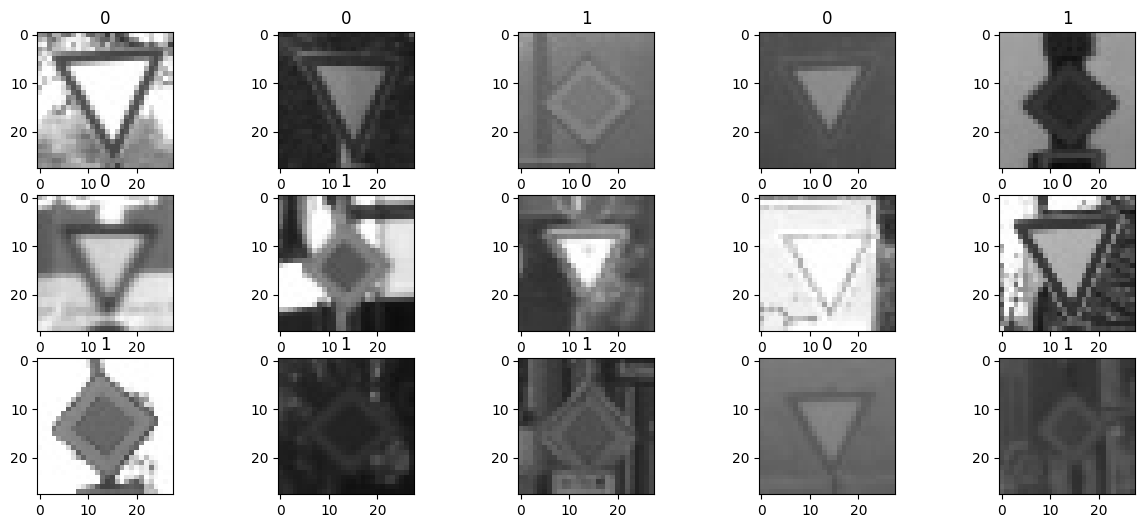

In [64]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 15)):    
    plt.subplot(3,5,cnt+1)
    plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels[idx])

#### Building the Neural Network

Let's now build our first (and yes, very simple) neural network using Tensorflow. For that, we will need a couple of new imports.

In [31]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input

The following netowork will consist of only one single neuron. It is a very tiny network (not even a network, strictly speaking :-) ) and yet it can be quite powerful.

In [66]:
inputs = Input(shape=(pixels.shape[1],))
outputs = Dense(1, activation="linear")(inputs) # один нейрон на виході з лінійною активацією

# створюємо нейронну мережу як повноцінну модель Keras (TensorFlow)
model = Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

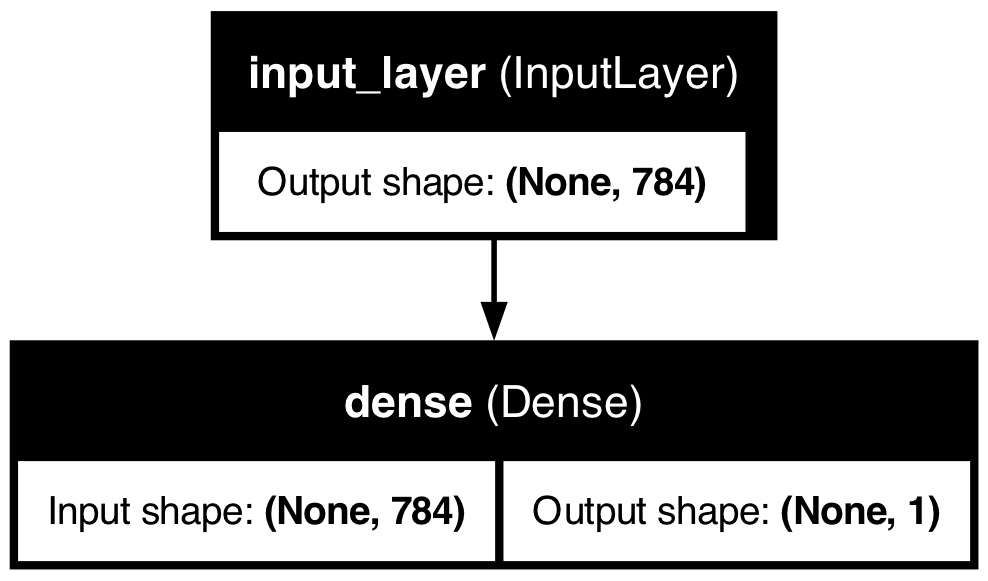

In [36]:
tf.keras.utils.plot_model(model, to_file="model.png", show_shapes=True, show_layer_names=True)

Before starting the training, we have to compile the model. During the compilation, we indicate what optimizer we want to use and what loss should be applied for the minimization process.

In [74]:
model.compile(optimizer ='adam', loss = 'mean_squared_error')

# Adam — це популярний адаптивний оптимізатор, який поєднує ідеї Momentum та RMSProp.
# Він автоматично підлаштовує швидкість навчання для кожного параметра окремо.
# Добре працює майже для всіх типів задач — від регресії до глибоких нейронних мереж.
# Зазвичай не вимагає ручного налаштування, що зручно для початку.

# Mean Squared Error (MSE) — це функція втрат, яка обчислює середній квадрат різниці між передбаченим значенням і правильним значенням

# Що відбувається після compile:
# Модель:
# - Знає, як рахувати помилку між передбаченням і правильним значенням.
# - Знає, як оновлювати ваги (через adam), щоб мінімізувати цю помилку.
# - Готова до запуску fit() — процесу навчання.

And let's train :-)

(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

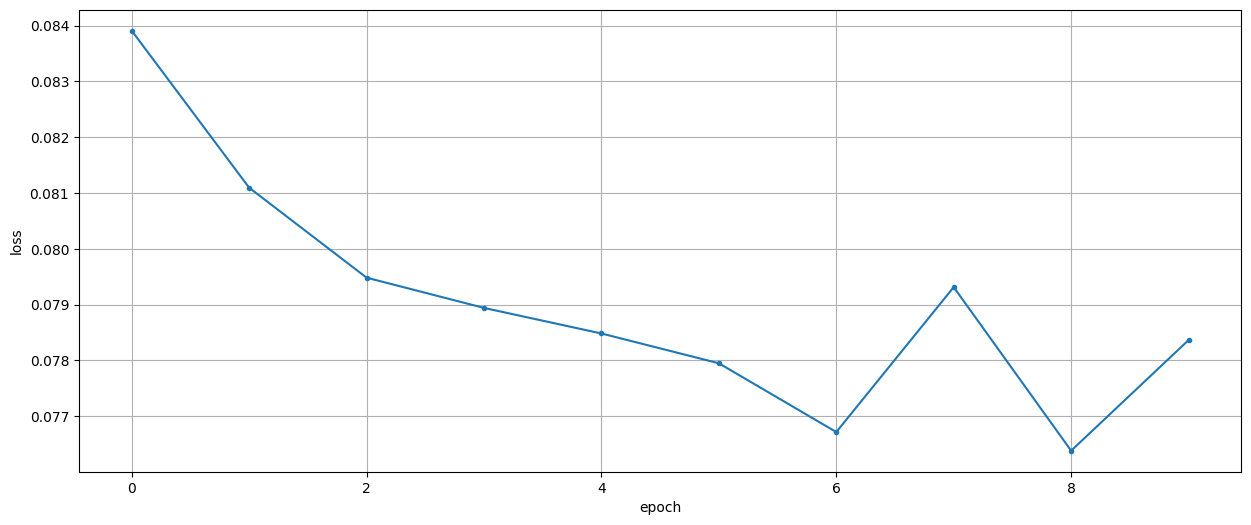

In [79]:
# Plot training history
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

In [78]:
# Навчання моделі
history = model.fit(pixels, labels, epochs=10, batch_size=32)

# pixels — вхідні дані (X)
# Це масив або тензор, який подається на вхід моделі.
# Розмір: (кількість_зразків, кількість_ознаків)
# Наприклад: (1000, 784) — 1000 зразків, кожен по 784 ознаки (наприклад, пікселі зображення).

# labels — правильні мітки (y)
# Це значення, які модель повинна навчитися передбачати.
# Якщо це регресія — просто числа (наприклад, температура).
# Якщо класифікація — класи (наприклад, 0 або 1).

# epochs=10 — кількість епох
# Епоха — це повний прохід по всьому датасету один раз.
# Якщо ви задали epochs=10, модель пройде датасет 10 разів, поступово вдосконалюючи ваги.
# Занадто мало епох → модель може не встигнути навчитися.
# Занадто багато → ризик перенавчання.

# batch_size=32 — розмір пакету (batch)
# Датасет не подається одразу цілим — його ділять на пакети (батчі).
# 32 означає, що модель обробляє 32 приклади за один крок, а потім оновлює ваги.
# Це компроміс між:
# 🐢 надто малий батч → стабільніше, але повільніше;
# 🚀 надто великий → швидше, але може бути гірша узагальнена здатність.

# history — об’єкт з результатами навчання
# Після тренування model.fit повертає History — об’єкт, який містить:
# втрати (loss) на кожній епосі,
# додаткові метрики (наприклад, accuracy, якщо вказані),
# інформацію про валідацію, якщо вона була.

Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0839
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0811  
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - loss: 0.0795
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - loss: 0.0789
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0785  
Epoch 6/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0779
Epoch 7/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0767
Epoch 8/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0793
Epoch 9/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0764
Epoch 10/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step - loss: 0.0784


[0.50790256] [0.50790256]


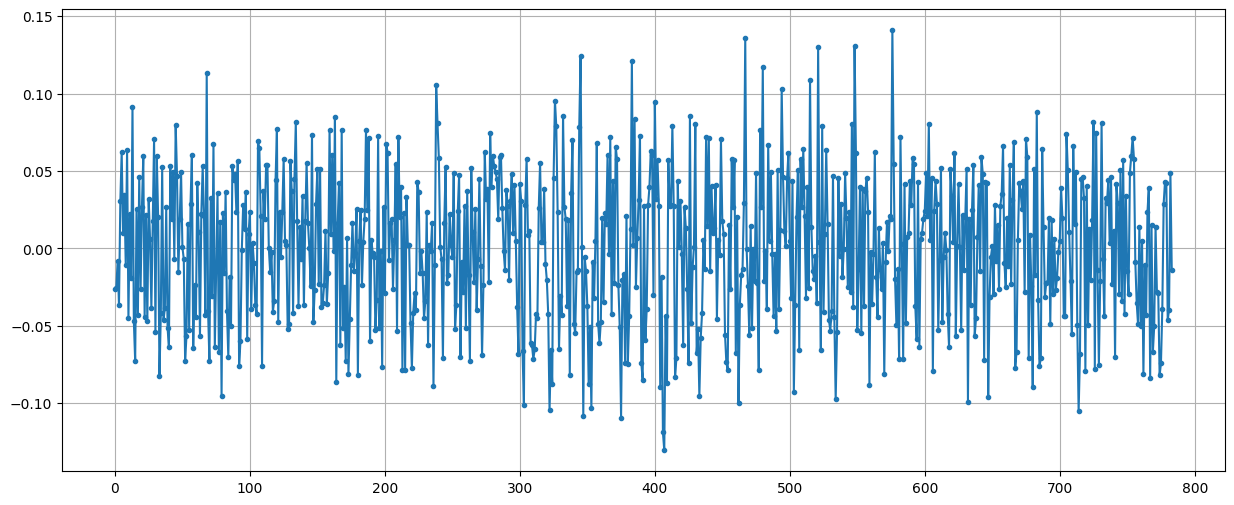

In [45]:
# Let's also have a looks at the learnt weights
# відображаються навчені параметри нейронної мережі — ваги (weights) та зсуви (bias) шару.
plt.plot(model.layers[1].weights[0].numpy(), '.-'), plt.grid(True)
print(model.layers[1].weights[1].numpy(), model.layers[1].bias.numpy())

#### Performance Evaluation

Once our model is trained, we will can run it on our images to see how it performs (inference).

In [84]:
idx = 50
pred = model.predict(pixels[idx:idx+1, ...])
print(pred, labels[idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
[[0.00723755]] 0


In [90]:
# Run it on the entire dataset
predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 706us/step


In [92]:
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

Accuracy 0.9610328638497653


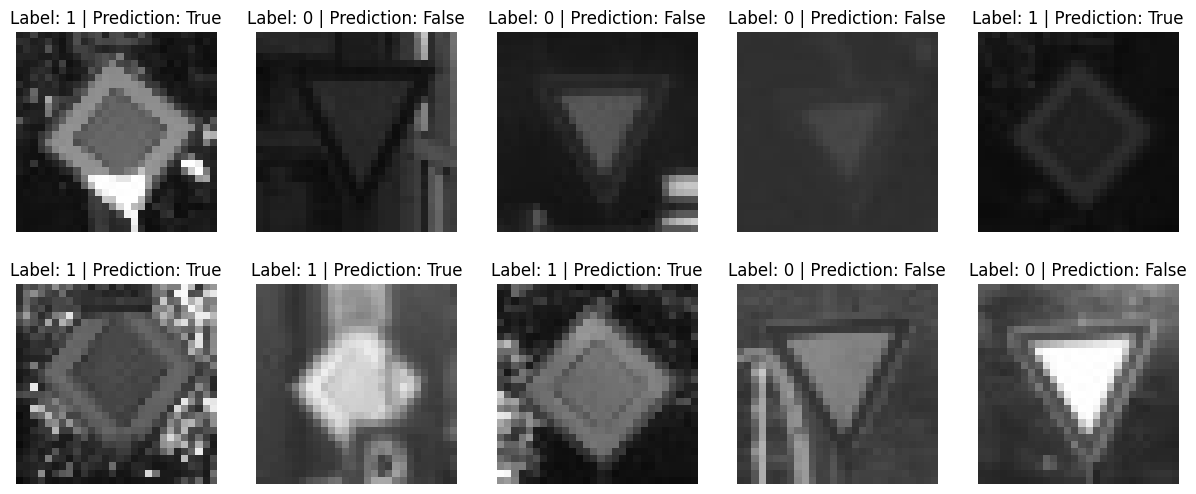

In [94]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)): 
    plt.subplot(2,5,cnt+1), plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title('Label: ' + str(labels[idx]) + ' | Prediction: ' + str(predictions[idx]))
    plt.axis(False)